<a href="https://colab.research.google.com/github/andrea-maza/PDS_MAEPS/blob/feature%2Fpca-andrea/PCA_Andrea_Maza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data engineering & cleaning

## Download, read and load the raw data



In [17]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import psycopg2
import re

In [18]:
!pip install gdown -q
!gdown --id 13NHW7x3PfT4URc8x0XSK9oZdNoebdrxS --output vw_cpt_brussels_params_completeset_20250318_remapped.parquet
raw = pd.read_parquet('vw_cpt_brussels_params_completeset_20250318_remapped.parquet')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13NHW7x3PfT4URc8x0XSK9oZdNoebdrxS
To: /content/vw_cpt_brussels_params_completeset_20250318_remapped.parquet
100% 64.6M/64.6M [00:00<00:00, 80.2MB/s]


In [19]:
raw = raw.drop(['index','sondeernummer','pkey_sondering'], axis=1)

In [20]:
raw.to_csv("cpt.csv", index=False)

In [21]:
print(raw.shape)
print(raw.head(3))
raw.describe().T

(1222711, 16)
   sondering_id         x         y  start_sondering_mtaw  \
0           314  153278.2  181734.6                 15.26   
1           314  153278.2  181734.6                 15.26   
2           314  153278.2  181734.6                 15.26   

   diepte_sondering_tot  diepte  diepte_mtaw    qc     fs        qtn  \
0                  25.4     1.6        13.66  1.17  0.035  35.894004   
1                  25.4     1.7        13.56  1.57  0.033  42.562319   
2                  25.4     1.8        13.46  1.43  0.036  38.536991   

         rf        fr       icn  sbt          ksbt lithostrat_id  
0  2.991453  3.058371  2.564340  5.0  1.434000e-07      Quartair  
1  2.101911  2.138968  2.406724  5.0  4.321000e-07      Quartair  
2  2.517483  2.569226  2.491219  5.0  2.392000e-07      Quartair  


,count,mean,std,min,25%,50%,75%,max
sondering_id,1222711.0,9062.646252,4515.799645,3.140000e+02,4.670000e+03,1.300900e+04,13231.000000,1.419600e+04
x,1222711.0,142565.647010,24461.694264,0.000000e+00,1.431274e+05,1.481266e+05,155919.090000,1.673159e+05
y,1222711.0,170324.112723,23133.945752,0.000000e+00,1.705420e+05,1.732079e+05,176790.370000,1.839144e+05
start_sondering_mtaw,1222711.0,56.753561,25.973815,0.000000e+00,4.102000e+01,5.431000e+01,68.080000,1.248300e+02
diepte_sondering_tot,1222711.0,18.395864,6.986045,0.000000e+00,1.386000e+01,2.002000e+01,21.180000,4.112000e+01
diepte,1222711.0,10.217873,6.709291,1.000000e-02,4.840000e+00,9.010000e+00,14.480000,4.112000e+01
diepte_mtaw,1222711.0,46.535688,26.562669,-2.998000e+01,2.969000e+01,4.335000e+01,60.510000,1.242300e+02
qc,1222711.0,7.646747,12.102972,6.365786e-08,2.286000e+00,4.773000e+00,10.720000,6.305791e+03
fs,1222711.0,0.158252,0.174845,5.431230e-05,5.230000e-02,9.770000e-02,0.200000,2.192540e+01
qtn,1222709.0,90.777872,153.901380,1.000000e-03,2.856503e+01,6.572096e+01,114.969208,8.136322e+04


## Database


In [22]:
# !pip -q install psycopg2-binary pandas python-dotenv

# ---------- 1) Connection (Supabase pooled port 6543 + SSL) ----------
user     = "postgres.vsqvzufrqjpjyulhetwl"
password = "MAEPSmaeps12345"
host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 6543
dbname   = "postgres"

def get_conn():
    return psycopg2.connect(
        host=host, port=port, dbname=dbname, user=user, password=password,
        sslmode="require"
    )

TABLE_STAGING = "stg_cpt_raw"

# ---------- 2) Sanitize columns (you already did this) ----------
def sanitize(name: str) -> str:
    s = re.sub(r'\s+', '_', str(name).strip())
    s = re.sub(r'[^0-9a-zA-Z_]', '_', s)
    if s and s[0].isdigit():
        s = '_' + s
    return s.lower()

raw = raw.copy()
orig2san, seen, new_cols = {}, set(), []
for c in raw.columns:
    base = sanitize(c)
    name = base
    i = 1
    while name in seen:
        name = f"{base}_{i}"; i += 1
    seen.add(name)
    orig2san[c] = name
    new_cols.append(name)
raw.columns = new_cols
print("Columns ->", raw.columns.tolist())

# ---------- 3) Create staging table ----------
ddl_cols = ",\n  ".join([f'"{c}" TEXT' for c in raw.columns])
ddl = f'CREATE TABLE IF NOT EXISTS {TABLE_STAGING} (\n  {ddl_cols}\n);'

with get_conn() as conn:
    conn.autocommit = True
    with conn.cursor() as cur:
        cur.execute(ddl)
print("Staging table ready.")


# ---------- 4) Bulk load DataFrame via COPY FROM STDIN ----------
cols_quoted = ", ".join([f'"{c}"' for c in raw.columns])
copy_sql = f"""
COPY {TABLE_STAGING} ({cols_quoted})
FROM STDIN WITH (FORMAT csv, HEADER true, DELIMITER ',', QUOTE '\"', NULL '');
"""

def copy_df(df_chunk: pd.DataFrame):
    buf = io.StringIO()
    df_chunk.to_csv(buf, index=False)  # header included
    buf.seek(0)
    with get_conn() as conn:
        with conn.cursor() as cur:
            cur.copy_expert(copy_sql, buf)
        conn.commit()

copy_df(raw)
print("Loaded DataFrame into staging table.")

# ---------- 5) Verify row count ----------
with get_conn() as conn:
    with conn.cursor() as cur:
        cur.execute(f"SELECT COUNT(*) FROM {TABLE_STAGING};")
        print("Rows in staging:", cur.fetchone()[0])

TYPED_TABLE = "cpt_brussels_params"
typed_sql = f"""
DROP TABLE IF EXISTS {TYPED_TABLE};
CREATE TABLE {TYPED_TABLE} AS
SELECT
  COALESCE(NULLIF(sondeernummer, ''), NULL)::text               AS sondeernummer,
  NULLIF(x, '')::double precision                               AS x,
  NULLIF(y, '')::double precision                               AS y,
  NULLIF(diepte_mtaw, '')::double precision                     AS diepte_mtaw,
  NULLIF(qc, '')::double precision                               AS qc,
  NULLIF(fs, '')::double precision                               AS fs,
  NULLIF(rf, '')::double precision                               AS rf
  -- TODO: add the rest of your columns with appropriate casts
FROM {TABLE_STAGING};

CREATE INDEX IF NOT EXISTS idx_{TYPED_TABLE}_sondeer ON {TYPED_TABLE}(sondeernummer);
CREATE INDEX IF NOT EXISTS idx_{TYPED_TABLE}_xy ON {TYPED_TABLE}(x, y);
"""


Columns -> ['sondering_id', 'x', 'y', 'start_sondering_mtaw', 'diepte_sondering_tot', 'diepte', 'diepte_mtaw', 'qc', 'fs', 'qtn', 'rf', 'fr', 'icn', 'sbt', 'ksbt', 'lithostrat_id']
Staging table ready.
Loaded DataFrame into staging table.
Rows in staging: 4890844


In [23]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# Reuse your get_conn() as-is (that’s fine for read-only SELECTs)
with get_conn() as conn:
    # a) sample
    lab_head = pd.read_sql("SELECT * FROM raw.labelled_cpt LIMIT 5;", conn)
    display(lab_head)

    # b) size
    lab_n = pd.read_sql("SELECT COUNT(*) AS n FROM raw.labelled_cpt;", conn)
    print(lab_n)

    # c) basic schema
    lab_cols = pd.read_sql("""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_schema='raw' AND table_name='labelled_cpt'
        ORDER BY ordinal_position;
    """, conn)
    display(lab_cols)


/tmp/ipython-input-3452760234.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lab_head = pd.read_sql("SELECT * FROM raw.labelled_cpt LIMIT 5;", conn)


,sondering_id,x,y,start_sondering_mtaw,diepte_sondering_tot,diepte,diepte_mtaw,qc,fs,qtn,rf,fr,icn,sbt,ksbt,lithostrat_id
0,314,153278.2,181734.6,15.26,25.4,1.6,13.66,1.17,0.035,35.89400438353187,2.991452991452992,3.0583711988815097,2.56434,5.0,1.434e-07,Quartair
1,314,153278.2,181734.6,15.26,25.4,1.7,13.56,1.57,0.033,42.56231931660572,2.1019108280254777,2.1389681099299973,2.406724,5.0,4.321e-07,Quartair
2,314,153278.2,181734.6,15.26,25.4,1.8,13.459999999999999,1.43,0.036,38.53699112706456,2.5174825174825175,2.5692263773908075,2.491219,5.0,2.392e-07,Quartair
3,314,153278.2,181734.6,15.26,25.4,1.9,13.36,0.5,0.024,15.678500768214604,4.8,5.111165775078922,2.982185,3.0,7.7e-09,Quartair
4,314,153278.2,181734.6,15.26,25.4,2.0,13.26,1.33,0.023,33.203118561084175,1.7293233082706767,1.7721100750416183,2.440158,5.0,3.419e-07,Quartair


/tmp/ipython-input-3452760234.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lab_n = pd.read_sql("SELECT COUNT(*) AS n FROM raw.labelled_cpt;", conn)


        n
0  225801


/tmp/ipython-input-3452760234.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lab_cols = pd.read_sql("""


,column_name,data_type
0,sondering_id,text
1,x,text
2,y,text
3,start_sondering_mtaw,text
4,diepte_sondering_tot,text
5,diepte,text
6,diepte_mtaw,text
7,qc,text
8,fs,text
9,qtn,text


## Separate labeled and unlabeled data


In [24]:
user     = "postgres.vsqvzufrqjpjyulhetwl"
password = "MAEPSmaeps12345"
host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 6543
dbname   = "postgres"

def get_conn():
    return psycopg2.connect(
        host=host, port=port, dbname=dbname, user=user, password=password,
        sslmode="require"
    )

query = "SELECT * FROM raw.labelled_cpt"

with get_conn() as conn:
    labeled_data = pd.read_sql(query, conn)

print("Data loaded from raw.labelled_cpt")
display(labeled_data.head())

/tmp/ipython-input-3431142227.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  labeled_data = pd.read_sql(query, conn)


Data loaded from raw.labelled_cpt


,sondering_id,x,y,start_sondering_mtaw,diepte_sondering_tot,diepte,diepte_mtaw,qc,fs,qtn,rf,fr,icn,sbt,ksbt,lithostrat_id
0,314,153278.2,181734.6,15.26,25.4,1.6,13.66,1.17,0.035,35.89400438353187,2.991452991452992,3.0583711988815097,2.56434,5.0,1.434e-07,Quartair
1,314,153278.2,181734.6,15.26,25.4,1.7,13.56,1.57,0.033,42.56231931660572,2.1019108280254777,2.1389681099299973,2.406724,5.0,4.321e-07,Quartair
2,314,153278.2,181734.6,15.26,25.4,1.8,13.459999999999999,1.43,0.036,38.53699112706456,2.5174825174825175,2.5692263773908075,2.491219,5.0,2.392e-07,Quartair
3,314,153278.2,181734.6,15.26,25.4,1.9,13.36,0.5,0.024,15.678500768214604,4.8,5.111165775078922,2.982185,3.0,7.7e-09,Quartair
4,314,153278.2,181734.6,15.26,25.4,2.0,13.26,1.33,0.023,33.203118561084175,1.7293233082706767,1.7721100750416183,2.440158,5.0,3.419e-07,Quartair


In [25]:
labeled_data = labeled_data.dropna(subset=['lithostrat_id'])

In [26]:
numeric_cols = ['x',
 'y',
 'start_sondering_mtaw',
 'diepte_sondering_tot',
 'diepte',
 'diepte_mtaw',
 'qc',
 'fs',
 'qtn',
 'rf',
 'fr',
 'icn',
 'sbt',
 'ksbt']
labeled_data[numeric_cols] = labeled_data[numeric_cols].apply(pd.to_numeric)

In [27]:
# Run only if we want to separate layers with two labels with + separator
# Split two layers in one label
labeled_data['lithostrat_id'] = labeled_data['lithostrat_id'].str.split(r'\s*\+\s*')

# Expand each list into multiple rows
labeled_data = labeled_data.explode('lithostrat_id', ignore_index=True)

In [28]:
# Check Missingness
labeled_data.describe(include='all')

,sondering_id,x,y,start_sondering_mtaw,diepte_sondering_tot,diepte,diepte_mtaw,qc,fs,qtn,rf,fr,icn,sbt,ksbt,lithostrat_id
count,218822,218822.000000,218822.000000,218822.000000,218822.000000,218822.000000,218822.000000,218822.000000,218822.000000,218822.000000,218822.000000,218822.000000,218773.000000,218773.000000,2.187730e+05,218822
unique,242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27
top,13081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quartair
freq,4490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50114
mean,NaN,150649.216542,174342.071564,60.100627,21.723184,11.259213,48.841414,7.952700,0.174011,90.440333,2.570948,2.743884,2.338821,4.890329,3.705080e-05,NaN
std,NaN,6462.125914,4269.471617,26.847864,7.138661,7.340794,28.042193,7.940515,0.178458,104.803228,3.366851,8.307316,0.421542,0.882305,1.132713e-03,NaN
min,NaN,139799.200000,164730.190000,14.330000,3.660000,0.020000,-13.830000,0.001000,0.000054,0.001000,0.002309,0.001000,0.431061,2.000000,0.000000e+00,NaN
25%,NaN,143840.930000,171235.341000,43.170000,17.100000,5.390000,30.420000,2.516000,0.059361,26.234499,1.452318,1.499007,2.034497,4.000000,6.130000e-08,NaN
50%,NaN,149920.320000,174577.300000,57.180000,20.390000,9.980000,46.100000,5.170000,0.106000,62.753447,2.360395,2.491909,2.311943,5.000000,8.389000e-07,NaN
75%,NaN,157138.660000,177974.630000,72.590000,26.590000,16.020000,64.670000,11.430000,0.236000,115.950845,3.342618,3.573753,2.685617,6.000000,5.849600e-06,NaN


{'whiskers': [<matplotlib.lines.Line2D at 0x79b6d2ff7fe0>,
 'caps': [<matplotlib.lines.Line2D at 0x79b6e11e53a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x79b6d296eff0>],
 'medians': [<matplotlib.lines.Line2D at 0x79b6e11e5190>],
 'fliers': [<matplotlib.lines.Line2D at 0x79b6e11e4140>],
 'means': []}

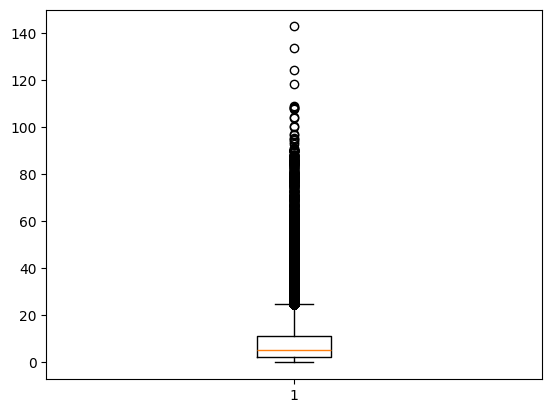

In [29]:
# Check Range
plt.boxplot(labeled_data['qc'])

{'whiskers': [<matplotlib.lines.Line2D at 0x79b6e1186db0>,
 'caps': [<matplotlib.lines.Line2D at 0x79b6e1184620>,
 'boxes': [<matplotlib.lines.Line2D at 0x79b6e11919a0>],
 'medians': [<matplotlib.lines.Line2D at 0x79b6e1186d20>],
 'fliers': [<matplotlib.lines.Line2D at 0x79b6e1186ff0>],
 'means': []}

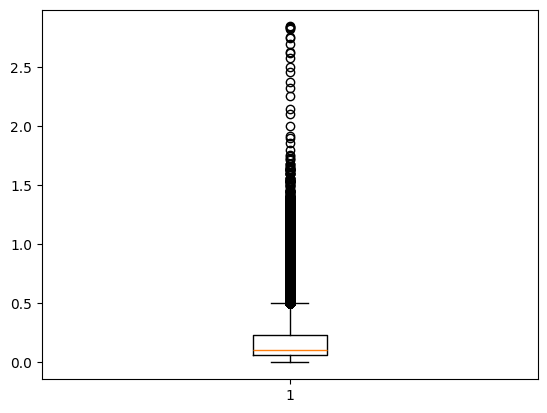

In [30]:
plt.boxplot(labeled_data['fs'])

In [31]:
# Add an ID column for lithostrat_id, only what we gathered from meeting (will add if file is uploaded)
layer_id = {'Quartair' : 1001,
'Diest' : 1002,
'Bolderberg' : 1003,
'Sint_Huibrechts_Hern' : 1005,
'Ursel' : 1007,
'Asse' : 1008,
'Wemmel' : 1009,
'Lede' : 1010,
'Brussel' : 1011,
'Merelbeke' : 1012,
'Kwatrecht' : 1013,
'Mont_Panisel' : 1014,
'Aalbeke' : 1015,
'Mons_en_Pevele' : 1016}

In [32]:
# No ID number layers as -1
labeled_data['lithostrat_num'] = labeled_data['lithostrat_id'].map(layer_id).fillna(-1).astype(int)

In [33]:
impt_layers_only = labeled_data[labeled_data['lithostrat_num'] != -1]

In [34]:
dummies = pd.get_dummies(impt_layers_only['lithostrat_id'])
impt_layers_only = pd.concat([impt_layers_only, dummies], axis=1)

In [35]:
impt_layers_only[['qc','fs', 'rf', 'diepte']].corr()

,qc,fs,rf,diepte
qc,1.000000,0.717708,-0.127398,0.213290
fs,0.717708,1.000000,0.119778,0.353803
rf,-0.127398,0.119778,1.000000,0.059884
diepte,0.213290,0.353803,0.059884,1.000000


In [36]:
impt_layers_only[['qc','fs', 'rf', 'diepte']].skew()

,0
qc,2.509485
fs,2.050141
rf,144.479634
diepte,0.695982


In [37]:
impt_layers_only['log_qc'] = np.log(impt_layers_only['qc'])
impt_layers_only['log_fs'] = np.log(impt_layers_only['fs'])
impt_layers_only['log_rf'] = np.log(impt_layers_only['rf'])

# PCA analysis

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_for_pca = impt_layers_only.copy()

num_cols = ['x','y','start_sondering_mtaw','diepte_sondering_tot','diepte',
            'diepte_mtaw','qc','fs','qtn','rf','fr','icn','sbt','ksbt',
            'log_qc','log_fs','log_rf']
for c in [c for c in num_cols if c in data_for_pca.columns]:
    data_for_pca[c] = pd.to_numeric(data_for_pca[c], errors='coerce')

In [87]:
layer_counts = data_for_pca['lithostrat_id'].value_counts().sort_values(ascending=False)
print(layer_counts)

lithostrat_id
Quartair                50114
Brussel                 24880
Mont_Panisel            24492
Lede                    22433
Mons_en_Pevele          18097
Aalbeke                 11465
Wemmel                   9176
Diest                    8711
Sint_Huibrechts_Hern     7985
Asse                     4906
Kwatrecht                4337
Ursel                    3964
Bolderberg               2181
Merelbeke                1144
Name: count, dtype: int64


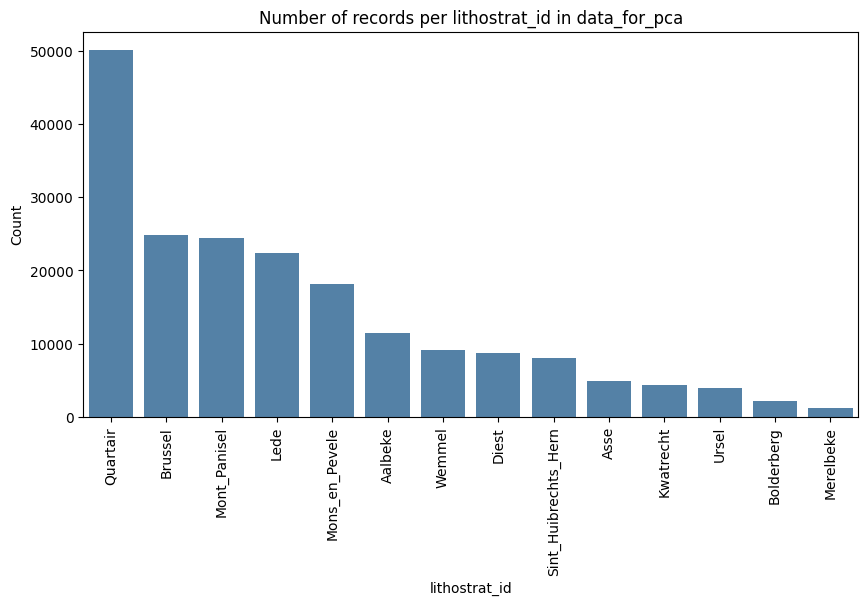

In [88]:
plt.figure(figsize=(10,5))
sns.barplot(x=layer_counts.index, y=layer_counts.values, color='steelblue')
plt.xticks(rotation=90)
plt.title('Number of records per lithostrat_id in data_for_pca')
plt.ylabel('Count')
plt.show()

| Layer                           | Rows          | Relative weight      |
| ------------------------------- | ------------- | -------------------- |
| **Quartair**                    | 50 114        | dominates (~30 %) |
| **Brussel, Mont_Panisel, Lede** | 22 000–25 000 | large                |
| **Aalbeke → Ursel**             | 4 000–11 000  | mid                  |
| **Bolderberg, Merelbeke**       | 1 000–2 000   | rare                 |

In [89]:
imbalance_ratio = layer_counts.max() / layer_counts.min()
print(f"Imbalance ratio: {imbalance_ratio:.1f}×")
#If it’s > 10×, the PCA will be dominated by the largest layers (e.g., Quartair).

Imbalance ratio: 43.8×


In [90]:
cpt_counts = data_for_pca.groupby('lithostrat_id')['sondering_id'].nunique().sort_values(ascending=False)
print(cpt_counts)
#That tells you how many distinct probes contribute to each layer type.

lithostrat_id
Quartair                166
Lede                     65
Brussel                  58
Mont_Panisel             55
Mons_en_Pevele           48
Wemmel                   45
Aalbeke                  41
Asse                     29
Kwatrecht                24
Ursel                    21
Sint_Huibrechts_Hern     11
Merelbeke                10
Bolderberg                7
Diest                     6
Name: sondering_id, dtype: int64


| Layer                              | CPT count | Comment                           |
| ---------------------------------- | --------- | --------------------------------- |
| **Quartair**                       | 166       | covers a very broad spatial range |
| **Lede / Brussel / Mont Panisel**  | 55–65     | good                              |
| **Bolderberg / Diest / Merelbeke** | < 10      | extremely under-represented       |


So not only that Quartair has more points, but also more distinct CPTs (166 probes vs. only 6 for Diest!).
So the sampling design itself is uneven.

----------------------------

**What this means for PCA**

* PCA (or UMAP) computes components that maximize overall variance.
* Because Quartair has 50 k points, it dominates that variance.
* Result: PC1 and PC2 mostly describe changes inside Quartair, not differences between layers.
* Rare layers (e.g. Diest, Bolderberg) appear compressed near the origin or overlapping.

To actually see how layers separate in feature space, we have to lithostrat_id to contribute roughly equally.

1) Per-layer summary (mean, std, min, max)

In [91]:
layer_stats = (data_for_pca
               .groupby('lithostrat_id')[['qc','fs','rf','diepte']]
               .agg(['mean','std','min','max'])
               .round(3))
display(layer_stats.head(20))

qc                             fs                \
                        mean     std    min      max   mean    std    min   
lithostrat_id                                                               
Aalbeke                2.632   1.263  0.053   29.220  0.094  0.030  0.005   
Asse                   2.915   0.973  0.940   11.313  0.096  0.041  0.006   
Bolderberg             3.561   2.731  0.180   19.000  0.082  0.054  0.002   
Brussel               14.870  11.350  0.288  109.030  0.209  0.221  0.001   
Diest                 14.711   5.359  1.736   69.341  0.392  0.203  0.016   
Kwatrecht              2.682   1.069  0.640   13.020  0.073  0.033  0.011   
Lede                  13.121   6.425  0.714  142.670  0.299  0.187  0.003   
Merelbeke              2.190   0.655  1.140    7.830  0.095  0.019  0.051   
Mons_en_Pevele        12.653   8.419  1.340   53.930  0.315  0.216  0.002   
Mont_Panisel           5.076   4.040  0.080   51.800  0.152  0.147  0.001   
Quartair               4.766   6.216  0.002   75.767  0.073  0.080  0.000   
Sint_Huibrechts_Hern   7.241   3.413  1.461   26.138  0.207  0.111  0.051   
Ursel                  1.825   0.581  0.620    4.850  0.076  0.030  0.009   
Wemmel                 8.734   4.104  0.790   35.610  0.317  0.134  0.012   

                                rf                         diepte         \
                        max   mean    std    min      max    mean    std   
lithostrat_id                                                              
Aalbeke               0.484  3.841  1.016  0.492   30.891  17.326  8.906   
Asse                  0.460  3.289  0.817  0.401    7.656  10.687  2.938   
Bolderberg            0.404  2.891  1.485  0.187   10.759   5.695  2.831   
Brussel               2.503  1.423  0.933  0.003   12.450  11.168  6.021   
Diest                 1.732  2.702  1.069  0.525    8.714   9.726  4.631   
Kwatrecht             0.410  2.775  0.671  0.374    7.821  16.132  4.727   
Lede                  1.537  2.189  0.946  0.052   11.686  15.055  5.680   
Merelbeke             0.190  4.495  0.743  2.133    8.082  12.721  3.256   
Mons_en_Pevele        1.406  2.787  1.262  0.037   10.890  18.449  6.387   
Mont_Panisel          0.906  2.936  1.256  0.021   19.845  17.280  7.729   
Quartair              1.210  2.232  5.512  0.002  793.750   5.359  3.570   
Sint_Huibrechts_Hern  0.646  3.145  1.418  0.641    9.851  10.201  4.474   
Ursel                 0.195  4.186  1.093  0.962    9.072   7.706  2.959   
Wemmel                0.895  3.915  1.534  0.359    9.766  13.047  3.504   

                                   
                       min    max  
lithostrat_id                      
Aalbeke               1.34  41.12  
Asse                  4.51  18.99  
Bolderberg            1.22  12.70  
Brussel               1.20  30.05  
Diest                 0.56  20.36  
Kwatrecht             5.92  29.69  
Lede                  2.01  28.53  
Merelbeke             7.11  18.40  
Mons_en_Pevele        3.01  39.94  
Mont_Panisel          0.02  35.50  
Quartair              0.02  20.00  
Sint_Huibrechts_Hern  2.51  19.92  
Ursel                 2.11  16.50  
Wemmel                4.00  20.29

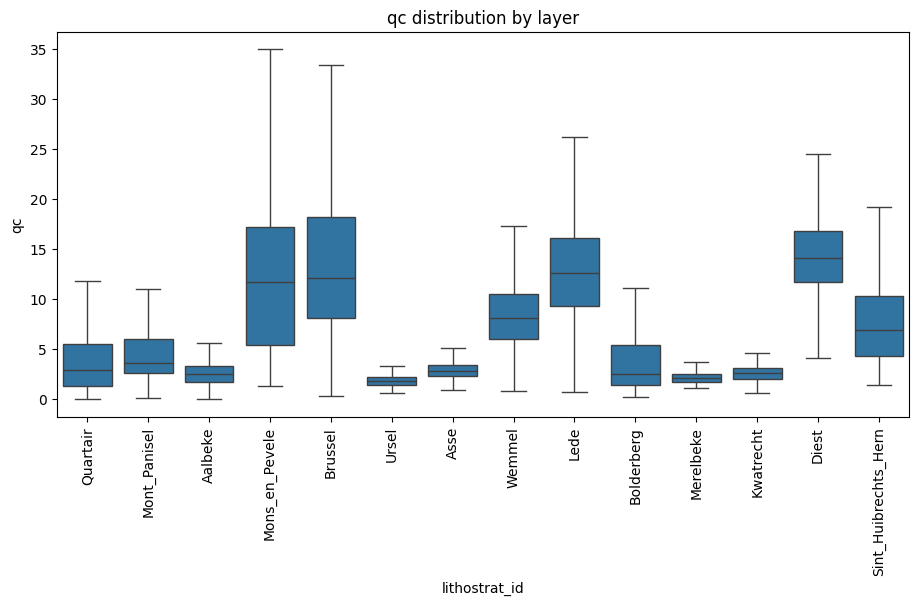

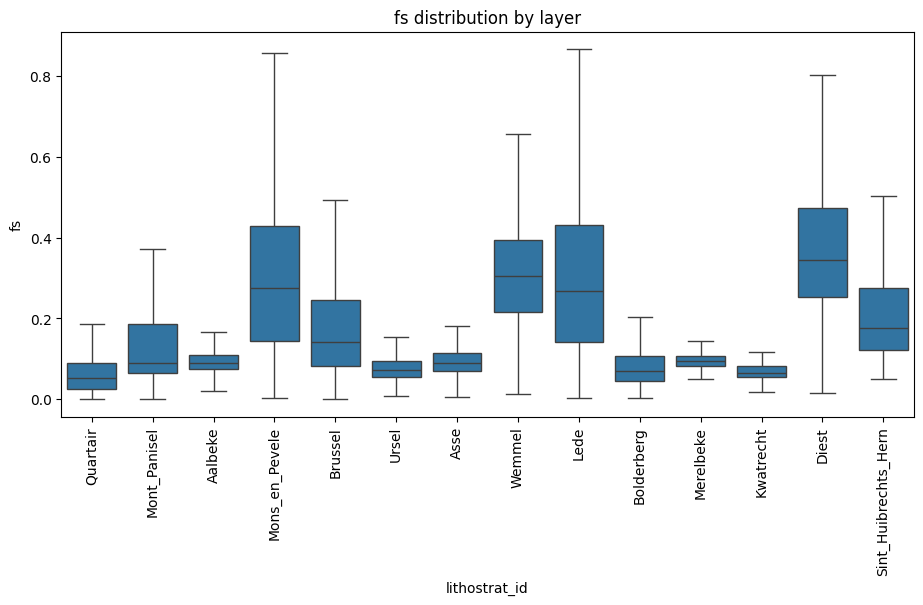

In [92]:
#Quick distribution plots (by layer):
plt.figure(figsize=(11,5))
sns.boxplot(x='lithostrat_id', y='qc', data=data_for_pca, showfliers=False)
plt.xticks(rotation=90); plt.title('qc distribution by layer'); plt.show()

plt.figure(figsize=(11,5))
sns.boxplot(x='lithostrat_id', y='fs', data=data_for_pca, showfliers=False)
plt.xticks(rotation=90); plt.title('fs distribution by layer'); plt.show()

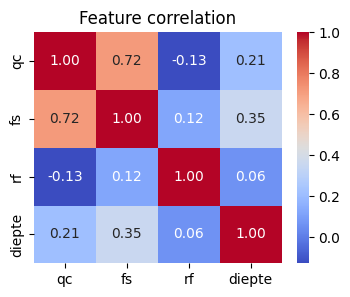

In [96]:
#Correlation among CPT features:
corr = data_for_pca[['qc','fs','rf','diepte']].corr()
plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f'); plt.title('Feature correlation'); plt.show()


#['x','y','start_sondering_mtaw','diepte_sondering_tot','diepte',
  #          'diepte_mtaw','qc','fs','qtn','rf','fr','icn','sbt','ksbt',

2) Build CPT×layer profiles (aggregates) for PCA/UMAP

In [94]:
#makes one row per (CPT, layer) with summary stats.
summary_feats = [c for c in ['qc','fs','rf','diepte','log_qc','log_fs','log_rf'] if c in data_for_pca.columns]
layer_profiles = (data_for_pca
                  .groupby(['sondering_id','lithostrat_id'])[summary_feats]
                  .agg(['mean','std','median'])
                  .reset_index())

# flatten multi-index columns
layer_profiles.columns = ['sondering_id','lithostrat_id'] + ['_'.join(col) for col in layer_profiles.columns[2:]]
display(layer_profiles.head())

,sondering_id,lithostrat_id,qc_mean,qc_std,qc_median,fs_mean,fs_std,fs_median,rf_mean,rf_std,...,diepte_median,log_qc_mean,log_qc_std,log_qc_median,log_fs_mean,log_fs_std,log_fs_median,log_rf_mean,log_rf_std,log_rf_median
0,1135,Brussel,9.141951,6.822197,7.005,0.154963,0.142830,0.1050,1.613190,0.774779,...,5.10,2.061468,0.494657,1.946622,-2.252750,1.044191,-2.254203,0.290952,0.861101,0.363488
1,1135,Quartair,2.850120,1.056026,2.520,0.045335,0.046263,0.0250,1.496951,1.495900,...,2.62,0.989116,0.337896,0.924259,-3.604641,1.054449,-3.688879,0.011414,0.880302,-0.050693
2,1156,Brussel,9.009440,6.256907,7.625,0.248054,0.182764,0.1750,2.753706,1.264607,...,8.04,2.087677,0.404481,2.031432,-1.578502,0.558930,-1.742969,0.938991,0.358726,0.856523
3,1156,Quartair,3.597429,1.930585,3.525,0.070729,0.040799,0.0675,2.026787,0.604624,...,2.01,1.115879,0.603979,1.259831,-2.823304,0.611623,-2.695655,0.665987,0.281182,0.645569
4,1158,Brussel,5.190611,4.587816,3.460,0.108798,0.122277,0.0495,1.851179,1.393821,...,9.73,1.271272,0.915870,1.241269,-3.067501,1.537320,-3.005834,0.266398,0.954071,0.538827


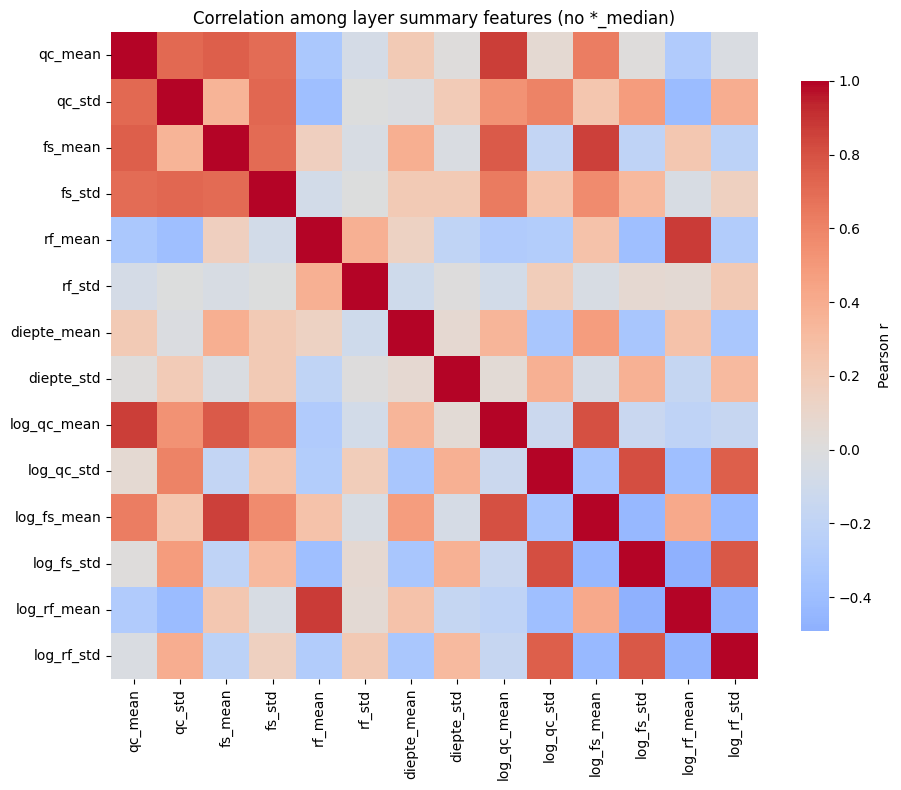

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# pick features for qc/fs/rf/diepte (includes log_* if present), EXCLUDING *_median
features = [
    c for c in layer_profiles.columns
    if any(v in c for v in ['qc','fs','rf','diepte'])          # keep only these variables
    and not c.endswith('_median')                               # drop medians
    and c not in ['sondering_id','lithostrat_id']               # drop IDs
]

# (optional) make sure they're numeric
corr = layer_profiles[features].apply(pd.to_numeric, errors='coerce').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True,
            cbar_kws={'shrink':0.85, 'label':'Pearson r'})
plt.title("Correlation among layer summary features (no *_median)")
plt.tight_layout()
plt.show()

In [103]:
max_rows_per_layer = 400  # tweak as needed
lp_bal = (layer_profiles.groupby('lithostrat_id', group_keys=False)
          .apply(lambda d: d.sample(min(len(d), max_rows_per_layer), random_state=42)))


/tmp/ipython-input-3806185424.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(len(d), max_rows_per_layer), random_state=42)))


3) PCA (linear)

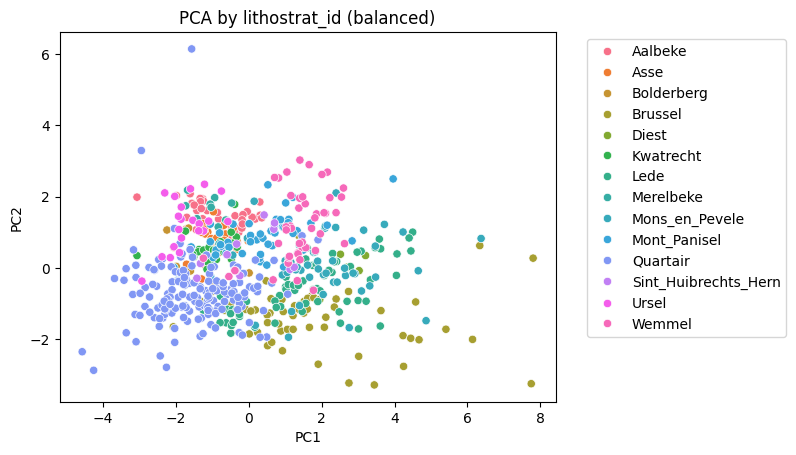

Explained variance ratio:
PC1: 59.06%
PC2: 23.18%


,PC1,PC2
log_qc_mean,0.495622,-0.230798
fs_mean,0.488179,0.131032
log_fs_mean,0.483208,0.253021
qc_mean,0.458148,-0.328259
diepte_mean,0.268824,0.350344
rf_mean,-0.019614,0.796899


,PC1,PC2
rf_mean,-0.019614,0.796899
diepte_mean,0.268824,0.350344
qc_mean,0.458148,-0.328259
log_fs_mean,0.483208,0.253021
log_qc_mean,0.495622,-0.230798
fs_mean,0.488179,0.131032


In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

reduced_features = ['qc_mean','fs_mean','rf_mean','diepte_mean','log_qc_mean','log_fs_mean']
X_scaled = StandardScaler().fit_transform(lp_bal[reduced_features])

features = [c for c in layer_profiles.columns if c not in ['sondering_id','lithostrat_id']]
#X_scaled = StandardScaler().fit_transform(lp_bal[features])

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
lp_bal['PC1'], lp_bal['PC2'] = pcs[:,0], pcs[:,1]

sns.scatterplot(x='PC1', y='PC2', hue='lithostrat_id', data=lp_bal)
plt.title('PCA by lithostrat_id (balanced)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("Explained variance ratio:")
for i, var in enumerate(pca.explained_variance_ratio_[:2], start=1):
    print(f"PC{i}: {var*100:.2f}%")

#Understand what features drive PC1 and PC2 (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=reduced_features)
display(loadings.sort_values('PC1', key=abs, ascending=False).head(10))
display(loadings.sort_values('PC2', key=abs, ascending=False).head(10))

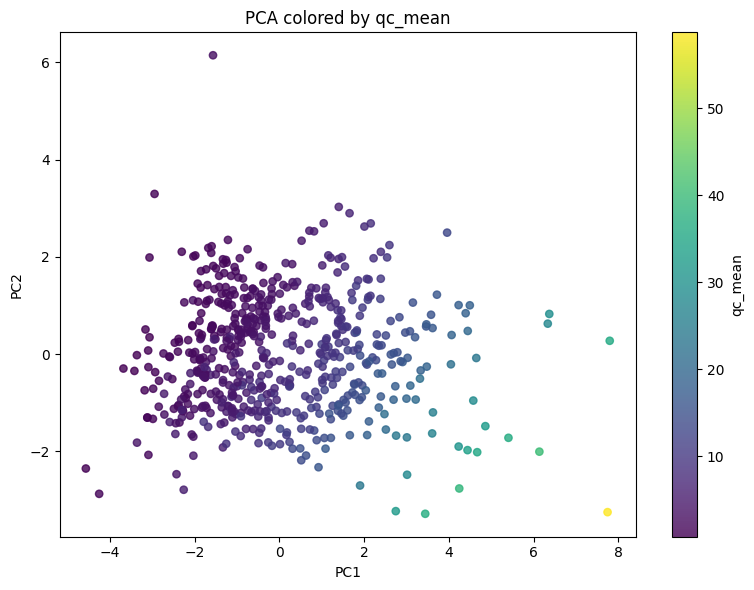

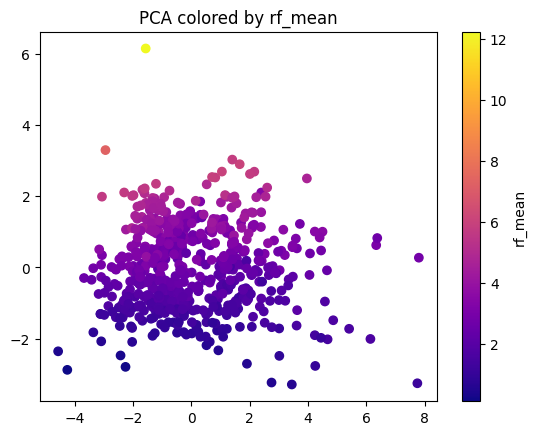

In [120]:
plt.figure(figsize=(8,6))
sc = plt.scatter(lp_bal['PC1'], lp_bal['PC2'],
                 c=lp_bal['qc_mean'], cmap='viridis', s=28, alpha=0.8)
plt.colorbar(sc, label='qc_mean')
plt.title('PCA colored by qc_mean')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()

sc = plt.scatter(lp_bal['PC1'], lp_bal['PC2'], c=lp_bal['rf_mean'], cmap='plasma')
plt.colorbar(sc, label='rf_mean')
plt.title('PCA colored by rf_mean')
plt.show()

Explained variance: [0.59057276 0.23182304 0.12175483]


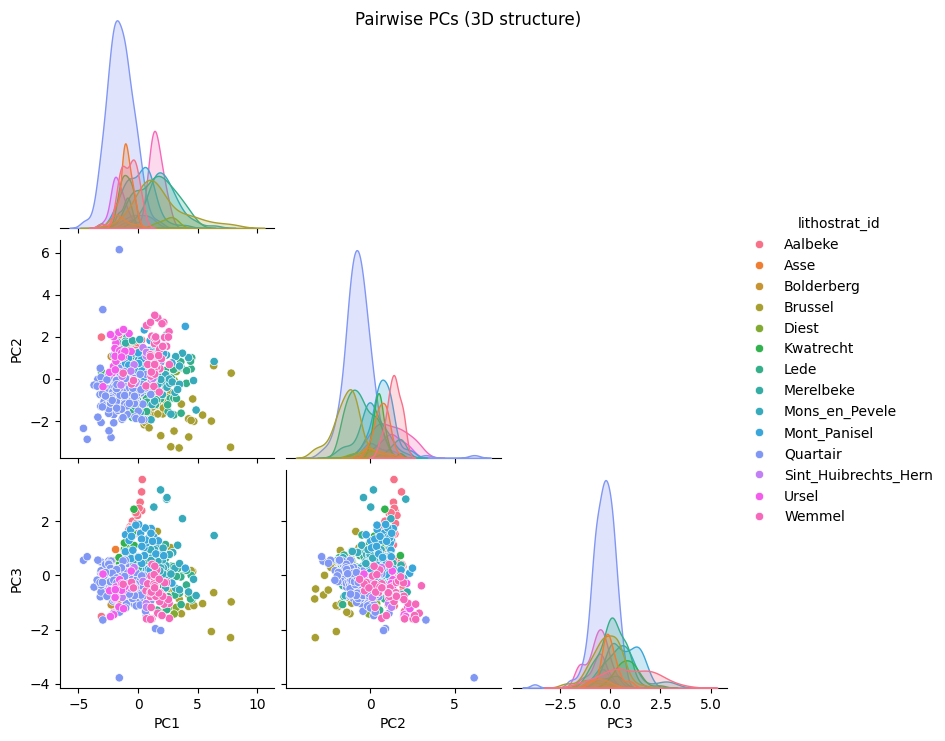

In [121]:
pca = PCA(n_components=3)
pcs = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_)
lp_bal['PC1'], lp_bal['PC2'], lp_bal['PC3'] = pcs[:,0], pcs[:,1], pcs[:,2]

sns.pairplot(lp_bal, vars=['PC1','PC2','PC3'], hue='lithostrat_id', corner=True)
plt.suptitle('Pairwise PCs (3D structure)')
plt.show()

Plot PC1–PC2:

4) UMAP (non-linear)

PCA is linear; if the layer relationships are nonlinear, UMAP or t-SNE works better:

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


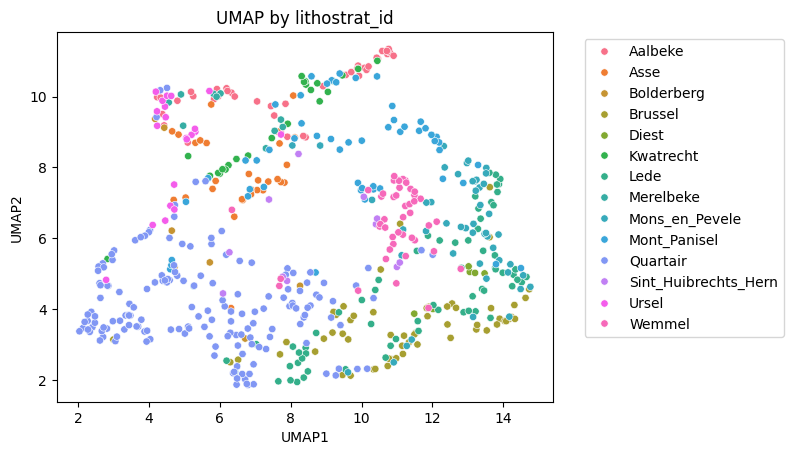

In [128]:
#!pip -q install umap-learn
from umap import UMAP
umap = UMAP(n_neighbors=15, min_dist=0.3, random_state=42)
emb = umap.fit_transform(X_scaled)
lp_bal['UMAP1'], lp_bal['UMAP2'] = emb[:,0], emb[:,1]

sns.scatterplot(x='UMAP1', y='UMAP2', hue='lithostrat_id', data=lp_bal, s=28)
plt.title('UMAP by lithostrat_id')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

In [129]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# --- KMeans on the 2D UMAP space ---
k = lp_bal['lithostrat_id'].nunique()   # same as number of layers
km = KMeans(n_clusters=k, random_state=42)
lp_bal['umap_cluster'] = km.fit_predict(lp_bal[['UMAP1','UMAP2']])

# --- Confusion matrix ---
cm = confusion_matrix(lp_bal['lithostrat_id'], lp_bal['umap_cluster'])
cm_df = pd.DataFrame(cm,
                     index=lp_bal['lithostrat_id'].unique(),
                     columns=[f"C{i}" for i in range(k)])

plt.figure(figsize=(10,7))
sns.heatmap(cm_df, cmap="Blues", annot=False)
plt.title("KMeans (UMAP) vs. True lithostrat_id")
plt.xlabel("KMeans Cluster"); plt.ylabel("True lithostrat_id")
plt.show()


ValueError: Mix of label input types (string and number)

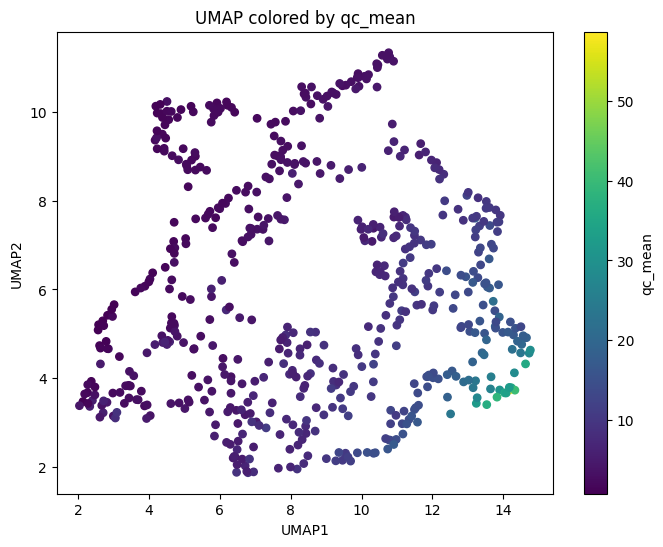

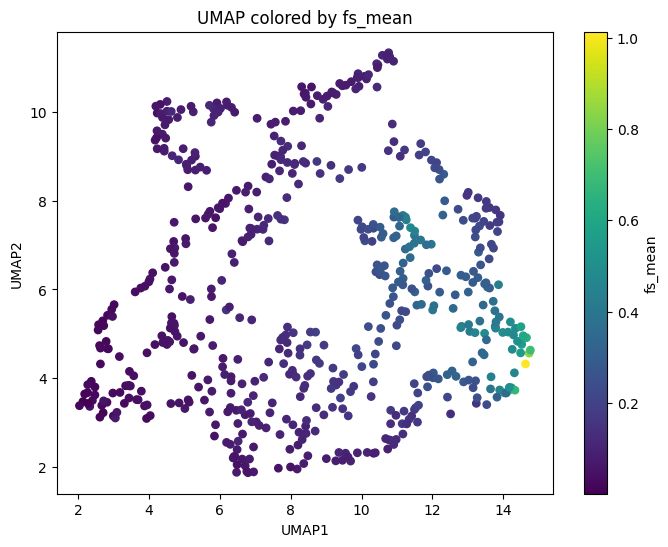

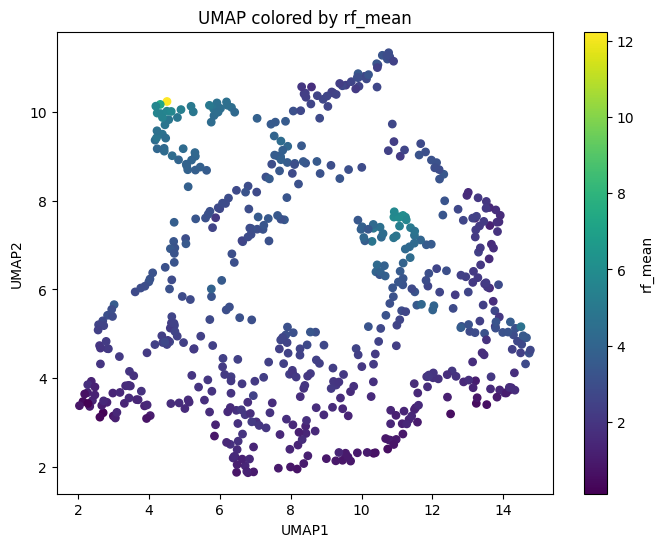

In [130]:
for col in ['qc_mean', 'fs_mean', 'rf_mean']:
    plt.figure(figsize=(8,6))
    sc = plt.scatter(lp_bal['UMAP1'], lp_bal['UMAP2'],
                     c=lp_bal[col], cmap='viridis', s=28)
    plt.colorbar(sc, label=col)
    plt.title(f"UMAP colored by {col}")
    plt.xlabel('UMAP1'); plt.ylabel('UMAP2')
    plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


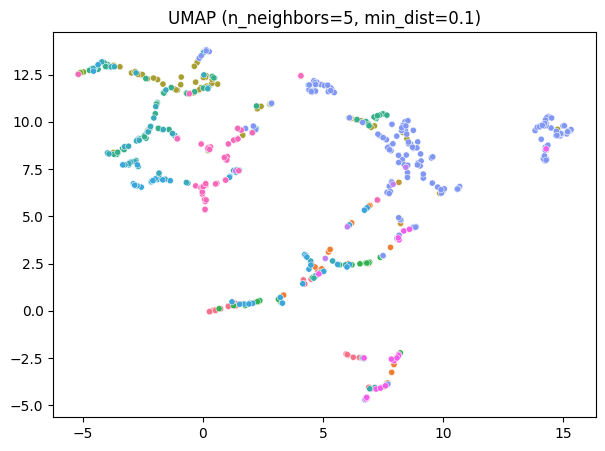

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


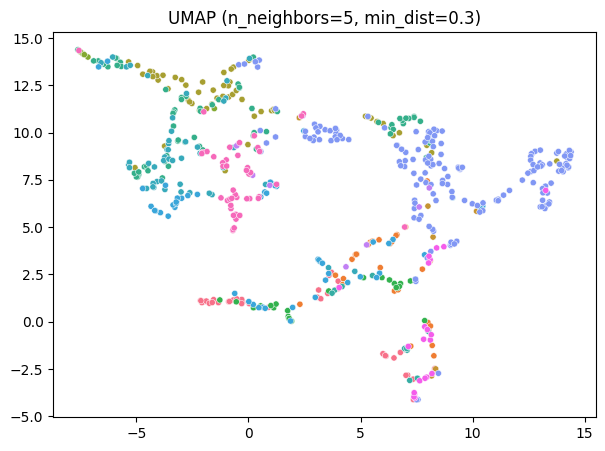

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


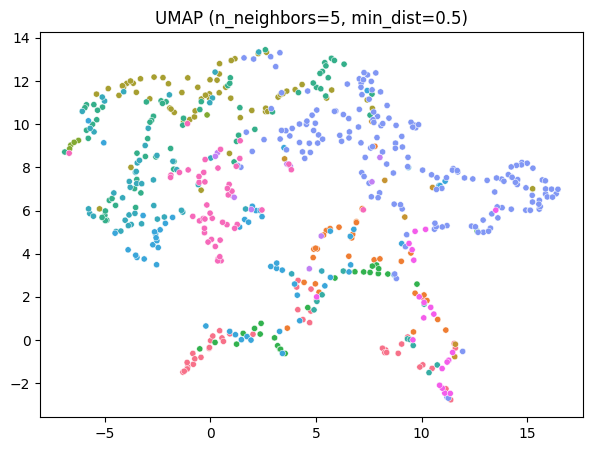

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


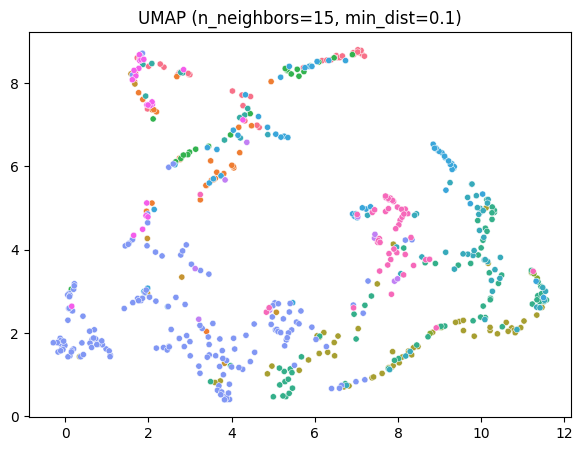

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


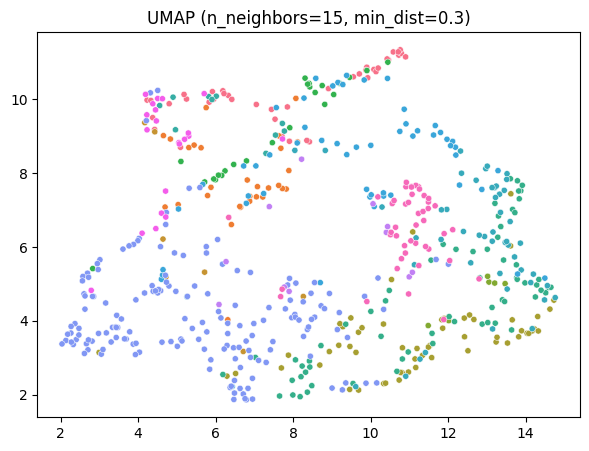

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


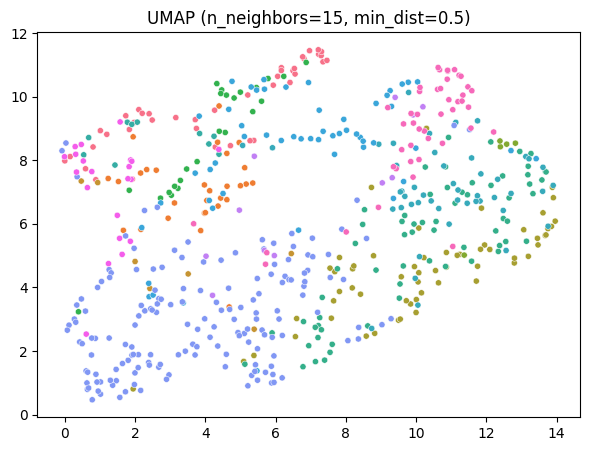

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


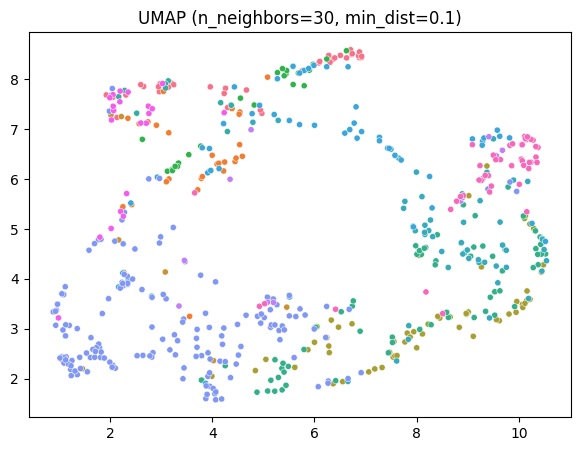

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


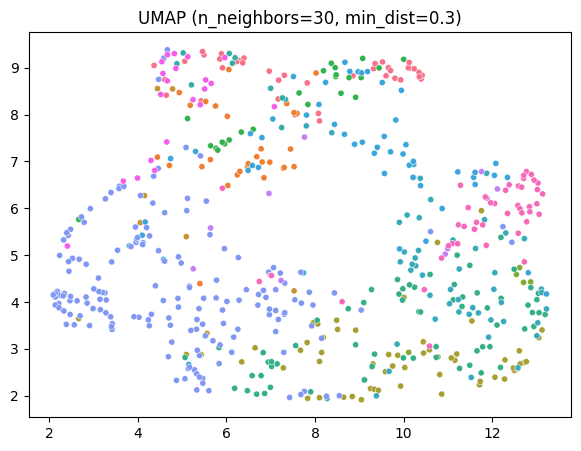

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


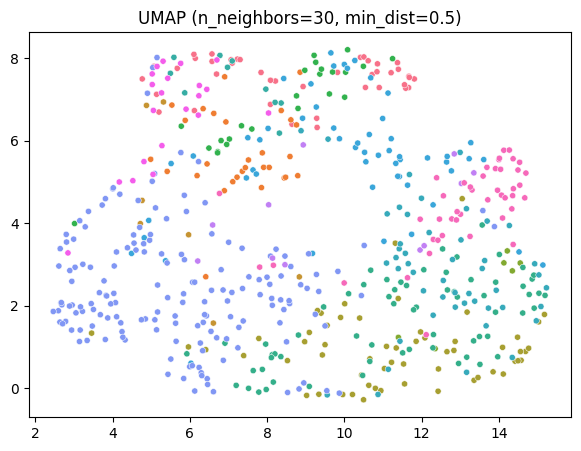

In [131]:
for n in [5, 15, 30]:
    for d in [0.1, 0.3, 0.5]:
        umap = UMAP(n_neighbors=n, min_dist=d, random_state=42)
        emb = umap.fit_transform(X_scaled)
        plt.figure(figsize=(7,5))
        sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=lp_bal['lithostrat_id'], s=20, legend=False)
        plt.title(f"UMAP (n_neighbors={n}, min_dist={d})")
        plt.show()


In [132]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(lp_bal[['UMAP1','UMAP2']], lp_bal['lithostrat_id'].astype('category').cat.codes)
print(f"Silhouette score (true lithostrat labels): {sil:.3f}")

sil_km = silhouette_score(lp_bal[['UMAP1','UMAP2']], lp_bal['umap_cluster'])
print(f"Silhouette score (KMeans clusters): {sil_km:.3f}")


Silhouette score (true lithostrat labels): -0.104
Silhouette score (KMeans clusters): 0.446


5) Compare with spatial proximity (x–y)

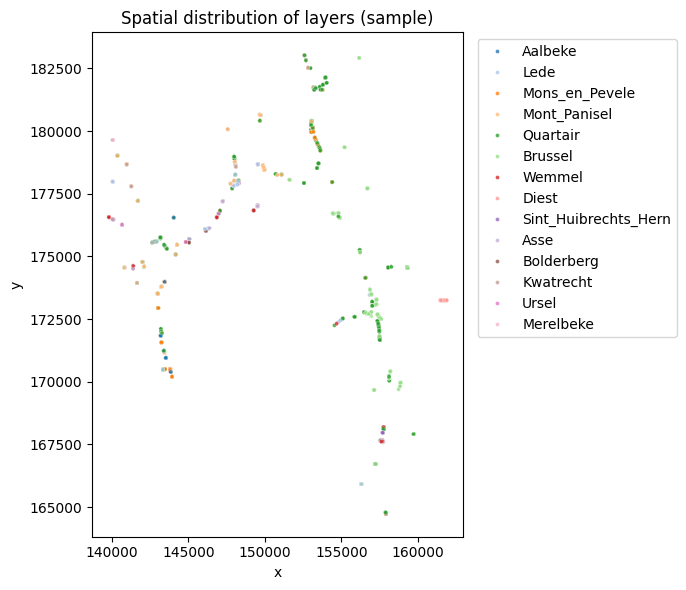

In [114]:
sample_xy = data_for_pca.sample(min(5000, len(data_for_pca)), random_state=0)
plt.figure(figsize=(7,6))
sns.scatterplot(data=sample_xy, x='x', y='y', hue='lithostrat_id', s=8, alpha=0.8, palette='tab20')
plt.title('Spatial distribution of layers (sample)'); plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout(); plt.show()

In [58]:
export_cols = ['sondering_id','lithostrat_id','PC1','PC2','UMAP1','UMAP2']
LP[export_cols].to_csv('layer_profiles_embeddings.csv', index=False)
print('Saved layer_profiles_embeddings.csv')

Saved layer_profiles_embeddings.csv


# Modeling prep

## Train, Test, Validation Datasets

In [ ]:
#excluded_ids = {4629, 3892, 3675, 4455, 4859, 14000, 4449} # Rare layers
#sondering_id = [i for i in labeled_data["sondering_id"].unique() if i not in excluded_ids]
sondering_id = labeled_data["sondering_id"].unique()
train_sondering_id = [i for i in sondering_id[:int(len(sondering_id)*0.9)]]
test_sondering_id = [i for i in sondering_id if i not in train_sondering_id]
impt_layers_only.groupby("lithostrat_id").agg(distinct_sondering_id=('sondering_id', 'nunique'), total_records=('sondering_id', 'count'),id=('sondering_id','max')).sort_values(by='distinct_sondering_id')

,distinct_sondering_id,total_records,id
lithostrat_id,,,
Diest,6,8711,4415
Bolderberg,7,2181,4678
Merelbeke,10,1144,4383
Sint_Huibrechts_Hern,11,7985,4919
Ursel,21,3964,4678
Kwatrecht,24,4337,4647
Asse,29,4906,4916
Aalbeke,41,11465,495
Wemmel,45,9176,4919


In [ ]:
X = impt_layers_only.drop('lithostrat_id', axis=1)
y = impt_layers_only['lithostrat_id']
x_train = X[X['sondering_id'].isin(train_sondering_id)]
x_test = X[X['sondering_id'].isin(test_sondering_id)]
y_train = y[X['sondering_id'].isin(train_sondering_id)]
y_test = y[X['sondering_id'].isin(test_sondering_id)]

print("Train-test split based on sondering_id complete.")
print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

Train-test split based on sondering_id complete.
Training set shape: (148161, 33)
Test set shape: (45724, 33)
